In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Clean section

In [ ]:
df = pd.read_excel("ML Project Dataset.xlsx")
df.head()

,Timestamp,What is the brand of your computer?,What is the CPU of your computer?,"How much RAM does the computer have? (GB)\n\nEx: 4, 8, 16, 32, ...","How much storage does the computer have? (GB)\n\nEx: 128, 256, 512, ...\nNote: 1T = 1024 GB","What size of your computer screen? (inches)\n\nEx: 15.6 , 17 , 24 , ....\nNote: Write ""None"", if you don't know or forget about it.","How much did you buy your computer? (Price in USD$)\n\nEx: 800, 1000, 1200, ...","What year did you buy your computer?\n\nEx: 2023, 2024, ..."
0,2026-03-07 18:46:25,ASUS,Intel core i5,16,1024,15.6,800,2024
1,2026-03-07 19:29:56,ASUS,Ryzen 8,16,256,15.6,800,2024
2,2026-03-07 19:45:13,Apple,M4,16,512,14,1200,2026
3,2026-03-07 19:47:51,ASUS,AMD Ryzen 7,16,1024,NaN,1300,2025
4,2026-03-07 19:50:06,ASUS,AMD Ryzen 7,16,512,15.6,800,2024


In [ ]:
mapping = {"What is the brand of your computer?":"Brand",
           "What is the CPU of your computer?":"CPU",
           "How much RAM does the computer have? (GB)\n\nEx: 4, 8, 16, 32, ...":"RAM",
           "How much storage does the computer have? (GB)\n\nEx: 128, 256, 512, ...\nNote: 1T = 1024 GB":"Storage",
           'What size of your computer screen? (inches)\n\nEx: 15.6 , 17 , 24 , ....\nNote: Write "None", if you don\'t know or forget about it.':"Screen",
            "How much did you buy your computer? (Price in USD$)\n\nEx: 800, 1000, 1200, ...":"Price",
            "What year did you buy your computer?\n\nEx: 2023, 2024, ...":"Year buy"}

df.rename(columns=mapping, inplace=True)
df

,Timestamp,Brand,CPU,RAM,Storage,Screen,Price,Year buy
0,2026-03-07 18:46:25,ASUS,Intel core i5,16,1024,15.6,800,2024
1,2026-03-07 19:29:56,ASUS,Ryzen 8,16,256,15.6,800,2024
2,2026-03-07 19:45:13,Apple,M4,16,512,14,1200,2026
3,2026-03-07 19:47:51,ASUS,AMD Ryzen 7,16,1024,NaN,1300,2025
4,2026-03-07 19:50:06,ASUS,AMD Ryzen 7,16,512,15.6,800,2024
5,2026-03-07 19:51:07,Dell,intel core i7,64,2048,15.6,1500,2024
6,2026-03-07 19:52:28,ASUS,AMD Ryzen 7,16,512,15.6,670,2024
7,2026-03-07 19:53:36,ASUS,AMD Ryzen 5,16 GB,512GB,15.6,774 USD,2024
8,2026-03-07 19:57:01,MSI,intel core i7,16,256,17.5,1099,2023
9,2026-03-07 19:59:59,Apple,M3,36,1024,14,1700,2025


In [ ]:
new_column_names = [
    "Timestamp", "Brand", "CPU", "RAM", "Storage", "Screen", "Price", "Year_Buy"
]
df.columns = new_column_names

df['RAM'] = df['RAM'].replace(r'GB|\s', '', regex=True).astype(float)

df['Storage'] = df['Storage'].astype(str)
df['Storage'] = df['Storage'].str.replace('1T', '1024', case=False)
df['Storage'] = df['Storage'].str.replace(r'GB|G|\s', '', regex=True, case=False)
df['Storage'] = pd.to_numeric(df['Storage'], errors='coerce')

df['Screen'] = pd.to_numeric(df['Screen'], errors='coerce')
df['Screen'] = df['Screen'].replace(['None', 'Forget'], np.nan)

df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace(r'[^\d.]', '', regex=True)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df['Year_Buy'] = df['Year_Buy'].astype(str).str.extract(r'(\d{4})')
df['Year_Buy'] = pd.to_numeric(df['Year_Buy'], errors='coerce')

df["CPU"] = df["CPU"].replace("Ryzen 8", "AMD Ryzen 7").astype(str)

## Dataset after cleaning

In [ ]:
df

,Timestamp,Brand,CPU,RAM,Storage,Screen,Price,Year_Buy
0,2026-03-07 18:46:25,ASUS,Intel core i5,16.0,1024,15.6,800.0,2024.0
1,2026-03-07 19:29:56,ASUS,AMD Ryzen 7,16.0,256,15.6,800.0,2024.0
2,2026-03-07 19:45:13,Apple,M4,16.0,512,14.0,1200.0,2026.0
3,2026-03-07 19:47:51,ASUS,AMD Ryzen 7,16.0,1024,NaN,1300.0,2025.0
4,2026-03-07 19:50:06,ASUS,AMD Ryzen 7,16.0,512,15.6,800.0,2024.0
5,2026-03-07 19:51:07,Dell,intel core i7,64.0,2048,15.6,1500.0,2024.0
6,2026-03-07 19:52:28,ASUS,AMD Ryzen 7,16.0,512,15.6,670.0,2024.0
7,2026-03-07 19:53:36,ASUS,AMD Ryzen 5,16.0,512,15.6,774.0,2024.0
8,2026-03-07 19:57:01,MSI,intel core i7,16.0,256,17.5,1099.0,2023.0
9,2026-03-07 19:59:59,Apple,M3,36.0,1024,14.0,1700.0,2025.0


## Feature engineering

In [ ]:
Brand_ratings = {
    'Apple': 9.0,
    'ASUS': 8.5,
    'Lenovo': 8.5,
    'Dell': 8.0,
    'MSI': 7.5,
    'Microsoft': 7.5,
    'Acer': 7.0
}

df['B.Rating'] = df['Brand'].map(Brand_ratings)

In [ ]:
def get_detailed_specs(row):
    cpu = str(row['CPU']).lower()
    year = row['Year_Buy']
    
     # --- APPLE SILICON (M-Series) ---
    if 'm1' in cpu: return 8, 8
    if 'm2' in cpu: return 8, 8
    if 'm3' in cpu: return 8, 8
    if 'm4' in cpu: return 10, 10 # Released 2024+
    if 'm5' in cpu: return 12, 12 # Future/2026 Prediction

    # --- INTEL CORE i3 (Entry Level) ---
    if 'i3' in cpu:
        if year >= 2024: return 8, 12  # 14th Gen (e.g., 14100 has 4P+0E = 4 cores, 8 threads, but newer i3 may get E-cores)
        if year >= 2022: return 4, 8   # 12th/13th Gen (4 cores, 8 threads)
        return 2, 4                     # Older Dual-core i3

    # --- INTEL CORE i5 (Mid Range) ---
    if 'i5' in cpu:
        if year >= 2024: return 14, 20  # 14th Gen (e.g., 14600K: 6P+8E = 14 cores, 20 threads)
        if year >= 2022: return 12, 16  # 12th/13th Gen Hybrid (e.g., 12600K: 6P+4E = 10 cores, 16 threads)
        if year >= 2018: return 6, 12   # 8th-11th Gen (6 cores, 12 threads)
        return 4, 4                      # Very old i5 (4 cores, 4 threads)

    # --- INTEL CORE i7 (High End) ---
    if 'i7' in cpu:
        if year >= 2024: return 16, 24  # 14th Gen (e.g., 14700K: 8P+12E = 20 cores, 28 threads, but laptop versions differ)
        if year >= 2022: return 14, 20  # 12th/13th Gen Hybrid (8P+8E = 16 cores, 24 threads for desktop, laptop lower)
        if year >= 2018: return 8, 16   # 8th-11th Gen (8 cores, 16 threads)
        return 4, 8                       # Older Quad-core i7

    # --- INTEL CORE i9 (Enthusiast) ---
    if 'i9' in cpu:
        if year >= 2024: return 24, 32  # 14th Gen (e.g., 14900K: 8P+16E = 24 cores, 32 threads)
        if year >= 2022: return 24, 32  # 12th/13th Gen (8P+16E for desktop)
        if year >= 2018: return 10, 20  # 9th-11th Gen (10 cores, 20 threads)
        return 8, 16                      # Very old i9 (8 cores, 16 threads)

    # --- AMD RYZEN 3 (Entry Level) ---
    if 'ryzen 3' in cpu or 'r3' in cpu:
        if year >= 2024: return 4, 8    # Zen 4 (4 cores, 8 threads)
        if year >= 2020: return 4, 8    # Zen 2/3 (4 cores, 8 threads)
        return 4, 4                        # Zen/Zen+ (4 cores, 4 threads)

    # --- AMD RYZEN 5 (Mid Range) ---
    if 'ryzen 5' in cpu or 'r5' in cpu:
        if year >= 2024: return 6, 12   # Zen 4 (6 cores, 12 threads)
        if year >= 2020: return 6, 12   # Zen 2/3 (6 cores, 12 threads)
        if year >= 2018: return 6, 12   # Zen+ (6 cores, 12 threads)
        return 4, 8                        # Zen (4 cores, 8 threads)

    # --- AMD RYZEN 7 (High End) ---
    if 'ryzen 7' in cpu or 'r7' in cpu:
        if year >= 2024: return 8, 16   # Zen 4/5 (8 cores, 16 threads)
        if year >= 2020: return 8, 16   # Zen 2/3 (8 cores, 16 threads)
        if year >= 2018: return 8, 16   # Zen+ (8 cores, 16 threads)
        return 8, 8                        # Zen (8 cores, 8 threads)

    # --- AMD RYZEN 9 (Enthusiast) ---
    if 'ryzen 9' in cpu or 'r9' in cpu:
        if year >= 2024: return 16, 32  # Zen 4/5 (e.g., 7950X: 16 cores, 32 threads)
        if year >= 2020: return 16, 32  # Zen 2/3 (e.g., 5950X: 16 cores, 32 threads)
        return 12, 24                       # Zen+ (12 cores, 24 threads)

    # --- AMD THREADRIPPER (Workstation) ---
    if 'threadripper' in cpu or 'tr' in cpu:
        if year >= 2022: return 64, 128 # Zen 3/4 Threadripper
        return 32, 64                       # Older Threadripper
        
    return np.nan, np.nan

# Create the columns by applying the function across the rows
df[['Cores', 'Threads']] = df.apply(
    lambda x: pd.Series(get_detailed_specs(x)), axis=1
)

## Dataset after preprocessing

In [ ]:
df

,Timestamp,Brand,CPU,RAM,Storage,Screen,Price,Year_Buy,B.Rating,Cores,Threads
0,2026-03-07 18:46:25,ASUS,Intel core i5,16.0,1024,15.6,800.0,2024.0,8.5,14,20
1,2026-03-07 19:29:56,ASUS,AMD Ryzen 7,16.0,256,15.6,800.0,2024.0,8.5,8,16
2,2026-03-07 19:45:13,Apple,M4,16.0,512,14.0,1200.0,2026.0,9.0,10,10
3,2026-03-07 19:47:51,ASUS,AMD Ryzen 7,16.0,1024,NaN,1300.0,2025.0,8.5,8,16
4,2026-03-07 19:50:06,ASUS,AMD Ryzen 7,16.0,512,15.6,800.0,2024.0,8.5,8,16
5,2026-03-07 19:51:07,Dell,intel core i7,64.0,2048,15.6,1500.0,2024.0,8.0,16,24
6,2026-03-07 19:52:28,ASUS,AMD Ryzen 7,16.0,512,15.6,670.0,2024.0,8.5,8,16
7,2026-03-07 19:53:36,ASUS,AMD Ryzen 5,16.0,512,15.6,774.0,2024.0,8.5,6,12
8,2026-03-07 19:57:01,MSI,intel core i7,16.0,256,17.5,1099.0,2023.0,7.5,14,20
9,2026-03-07 19:59:59,Apple,M3,36.0,1024,14.0,1700.0,2025.0,9.0,8,8


# Visualization

### Linear regression

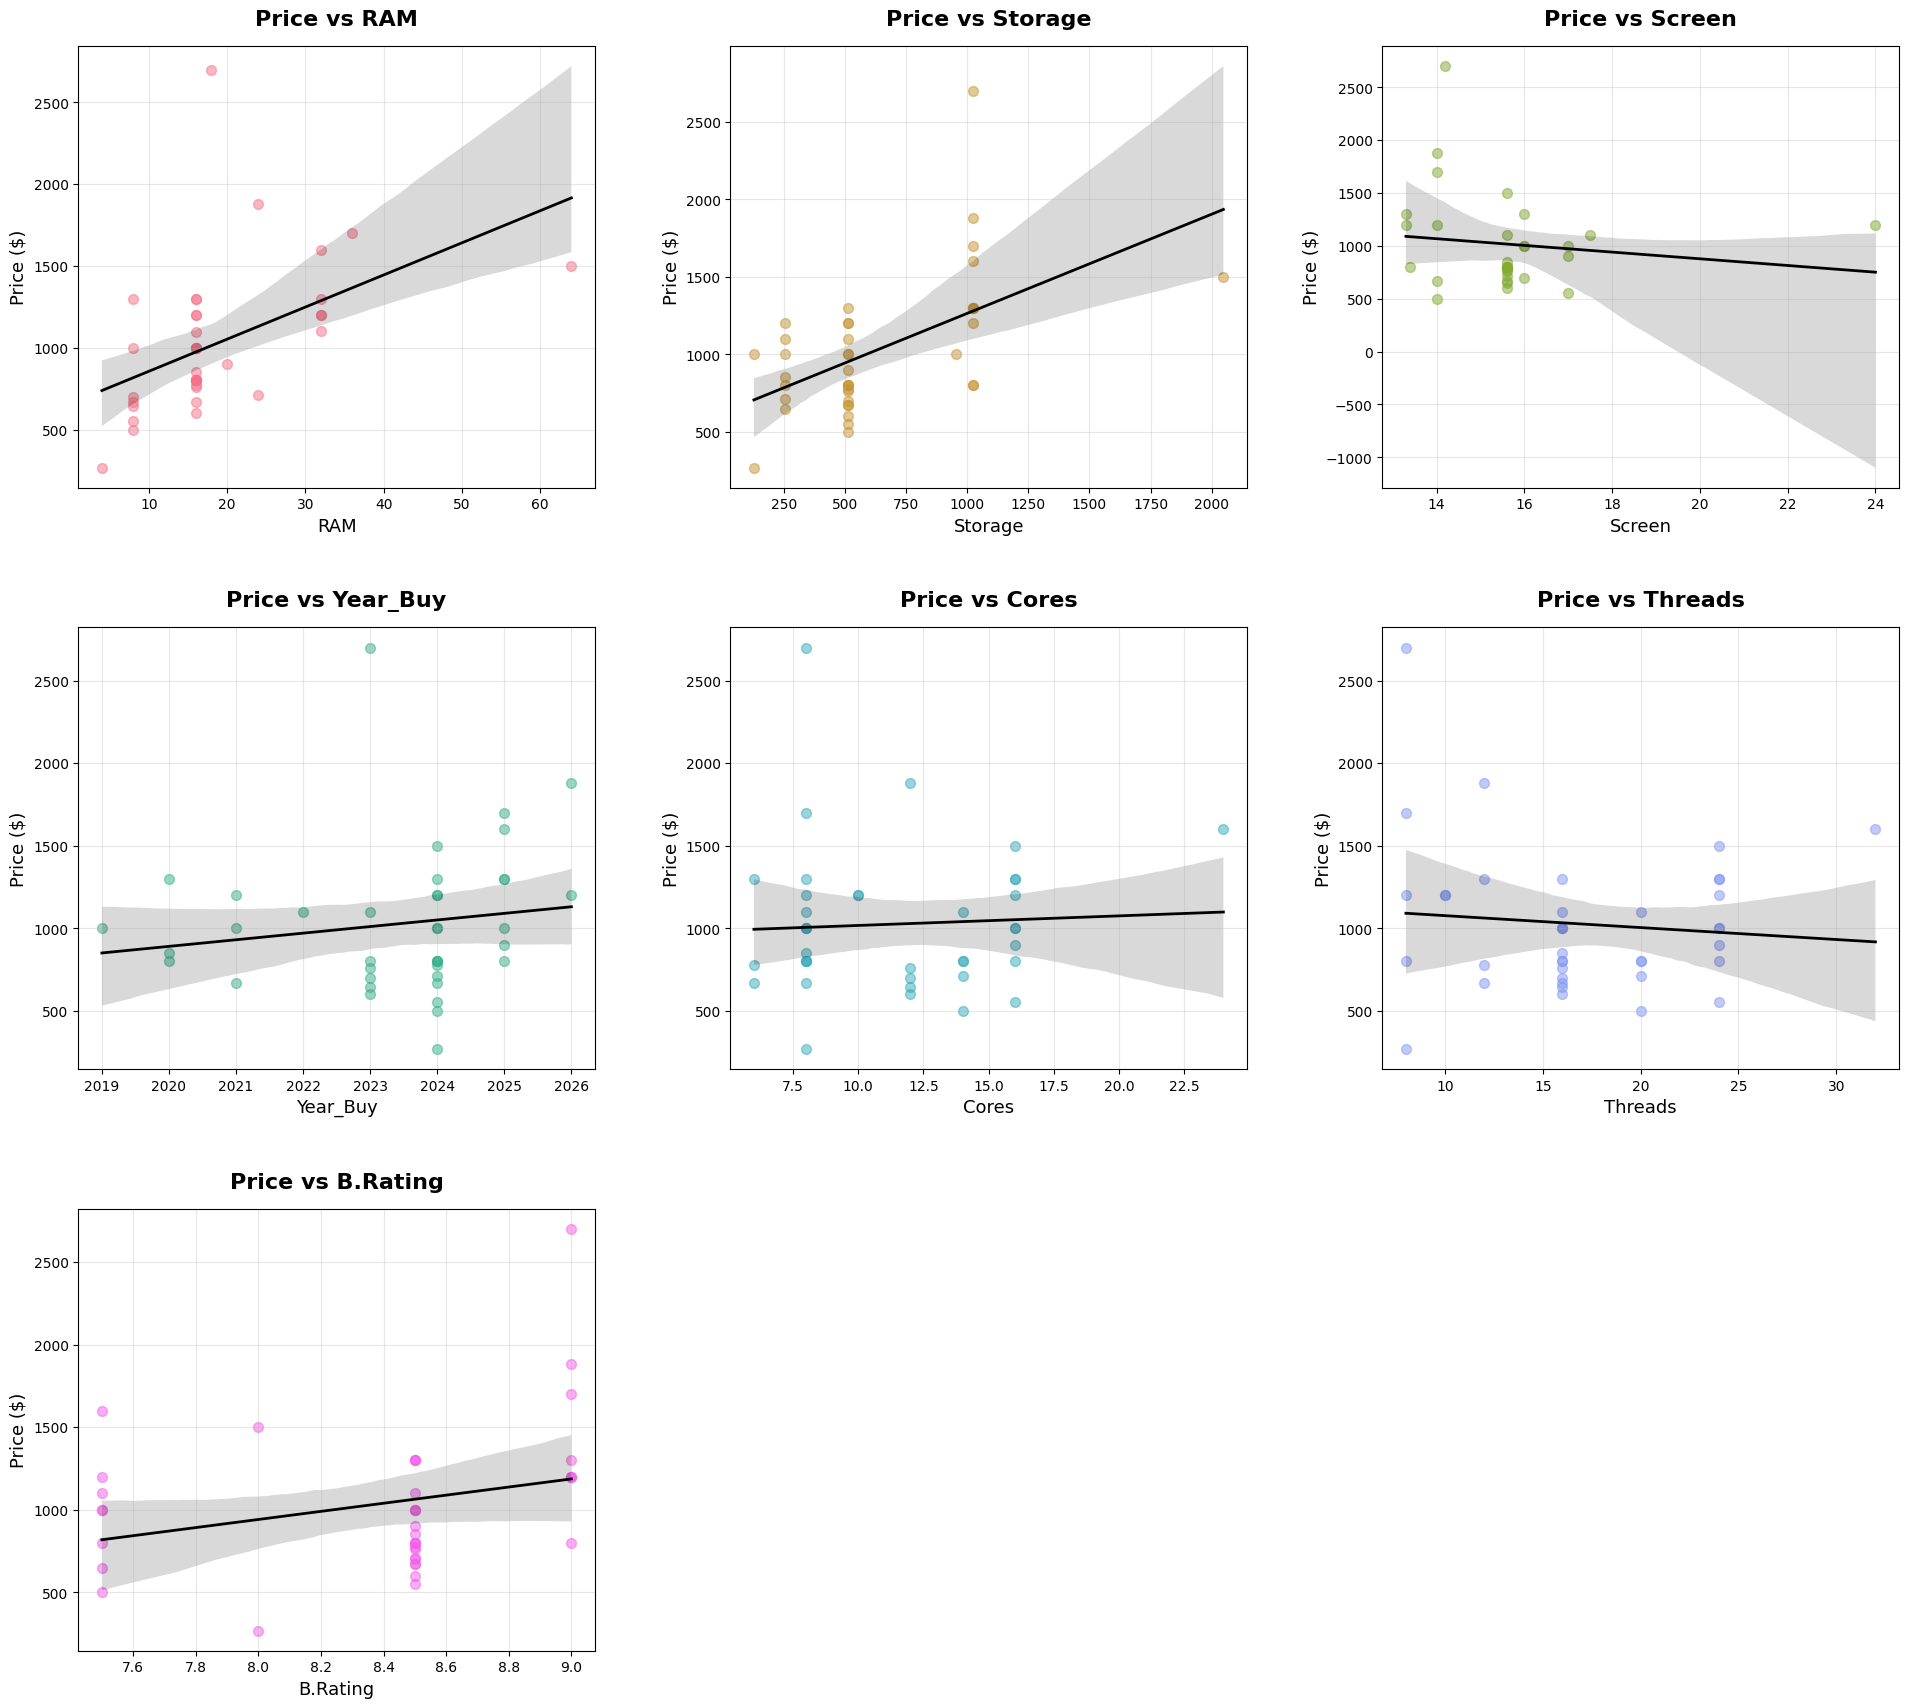

In [ ]:
# 1. Define the numerical columns
cols_to_plot = ['RAM', 'Storage', 'Screen', 'Year_Buy', 'Cores', 'Threads', 'B.Rating']

# 2. Create a list of distinct colors for each graph
colors = sns.color_palette("husl", len(cols_to_plot))

# 3. Setup the 3x3 gridz
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

# 4. Loop through columns, colors, and plot positions
for i, (col, color) in enumerate(zip(cols_to_plot, colors)):
    if col in df.columns:
        # sns.regplot adds the dots AND the regression line automatically
        sns.regplot(
            data=df, 
            x=col, 
            y='Price', 
            ax=axes[i], 
            color=color,           # Each plot gets a different color
            scatter_kws={'alpha':0.5, 's':50}, # Adjust dot transparency and size
            line_kws={'color':'black', 'lw':2}  # Make the regression line stand out
        )
        
        # Adding titles and clear labels
        axes[i].set_title(f'Price vs {col}', fontsize=16, fontweight='bold', pad=15)
        axes[i].set_xlabel(col, fontsize=13)
        axes[i].set_ylabel('Price ($)', fontsize=13)
        axes[i].grid(True, alpha=0.3)

# 5. Hide the two empty subplots at the bottom right
for j in range(len(cols_to_plot), 9):
    axes[j].set_visible(False)

# 6. Adjust layout to prevent overlapping labels
plt.tight_layout(pad=4.0)

### Heatmap

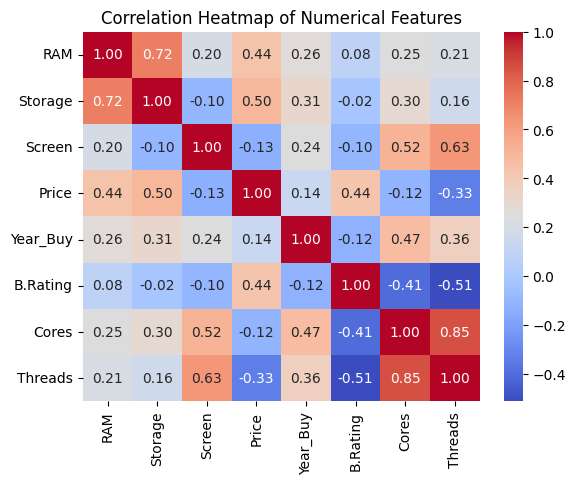

In [ ]:
# Select all numerical columns automatically
numerical_cols = df.select_dtypes(include=['float64', 'int64']).dropna()

if not numerical_cols.empty:
    sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap of Numerical Features")
    plt.show()
else:
    print("No numerical columns found")


# Training for model

### Feature selecting

In [ ]:
# 1. Standardize column names to match your current DataFrame
df.columns = ["Timestamp", "Brand", "CPU", "RAM", "Storage", "Screen", "Price", "Year_Buy", "B.Rating", "Cores", "Threads"]

# 2. Define the numerical columns for your matrix WITHOUT 'Price'
numerical_cols = ['RAM', 'Storage', 'Screen', 'Year_Buy', 'B.Rating', 'Cores', 'Threads']

# 3. Handle NaN values by filling with the Mean
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

# 4. Extract the Feature Matrix (X)
X_matrix = df[numerical_cols].values

# 5. Extract the Target Vector (y) - Price (Handle NaNs in target if any exist)
df['Price'] = df['Price'].fillna(df['Price'].mean()) # Good practice just in case
y_vector = df['Price'].values

print("Feature Matrix (X) Shape:", X_matrix.shape)
print("Target Vector (y) Shape:", y_vector.shape)

Feature Matrix (X) Shape: (40, 7)
Target Vector (y) Shape: (40,)


### Feature scaling

In [ ]:
# feature scalling
x_mean = np.mean(X_matrix, axis=0)
x_std = np.std(X_matrix, axis=0)
x_scaled=(X_matrix-x_mean)/x_std
print(x_scaled.shape)
print(x_scaled[:5])

(40, 7)
[[-0.21992652  1.08630785  0.00187704  0.36903211  0.3086067   0.64571962
   0.54025814]
 [-0.21992652 -0.95737989  0.00187704  0.36903211  0.3086067  -0.76312318
  -0.11460021]
 [-0.21992652 -0.27615064 -0.95916761  1.56838648  1.2344268  -0.29350892
  -1.09688773]
 [-0.21992652  1.08630785  0.          0.9687093   0.3086067  -0.76312318
  -0.11460021]
 [-0.21992652 -0.27615064  0.00187704  0.36903211  0.3086067  -0.76312318
  -0.11460021]]


### Concatenat input variable

In [ ]:
# concatenate x_scaled with a column of 1s
x_new = np.concatenate((np.ones((X_matrix.shape[0], 1)), X_matrix), axis=1)
print(x_new.shape)
print(x_new[:])

(40, 8)
[[1.00000000e+00 1.60000000e+01 1.02400000e+03 1.56000000e+01
  2.02400000e+03 8.50000000e+00 1.40000000e+01 2.00000000e+01]
 [1.00000000e+00 1.60000000e+01 2.56000000e+02 1.56000000e+01
  2.02400000e+03 8.50000000e+00 8.00000000e+00 1.60000000e+01]
 [1.00000000e+00 1.60000000e+01 5.12000000e+02 1.40000000e+01
  2.02600000e+03 9.00000000e+00 1.00000000e+01 1.00000000e+01]
 [1.00000000e+00 1.60000000e+01 1.02400000e+03 1.55968750e+01
  2.02500000e+03 8.50000000e+00 8.00000000e+00 1.60000000e+01]
 [1.00000000e+00 1.60000000e+01 5.12000000e+02 1.56000000e+01
  2.02400000e+03 8.50000000e+00 8.00000000e+00 1.60000000e+01]
 [1.00000000e+00 6.40000000e+01 2.04800000e+03 1.56000000e+01
  2.02400000e+03 8.00000000e+00 1.60000000e+01 2.40000000e+01]
 [1.00000000e+00 1.60000000e+01 5.12000000e+02 1.56000000e+01
  2.02400000e+03 8.50000000e+00 8.00000000e+00 1.60000000e+01]
 [1.00000000e+00 1.60000000e+01 5.12000000e+02 1.56000000e+01
  2.02400000e+03 8.50000000e+00 6.00000000e+00 1.200000

### Reshape out put variable

In [ ]:
y_new = y_vector.reshape(-1,1)
y_new.shape

(40, 1)

### Training linear regression model

In [ ]:
# Training
theta =np.zeros((x_new.shape[1],1))
lr = 0.0000001
cost_hist =[]
for i in range (1,1001):
    Y_hat = np.matmul(x_new ,theta)
    cost = np.mean((Y_hat - y_new)**2)
    cost_hist.append(cost)
    grad = (2/len(y_new)) * np.matmul(x_new.T, (Y_hat -y_new))

    #update weights
    theta = theta - lr*grad
    print(f"Interation: {i:03d}, cost:{cost:0.4f}")
    


Interation: 001, cost:1233803.6109
Interation: 002, cost:170652.0408
Interation: 003, cost:157986.7277
Interation: 004, cost:156464.2765
Interation: 005, cost:155129.8809
Interation: 006, cost:153864.5217
Interation: 007, cost:152663.5336
Interation: 008, cost:151523.6298
Interation: 009, cost:150441.7024
Interation: 010, cost:149414.8021
Interation: 011, cost:148440.1296
Interation: 012, cost:147515.0277
Interation: 013, cost:146636.9747
Interation: 014, cost:145803.5772
Interation: 015, cost:145012.5633
Interation: 016, cost:144261.7768
Interation: 017, cost:143549.1713
Interation: 018, cost:142872.8044
Interation: 019, cost:142230.8325
Interation: 020, cost:141621.5058
Interation: 021, cost:141043.1636
Interation: 022, cost:140494.2296
Interation: 023, cost:139973.2078
Interation: 024, cost:139478.6781
Interation: 025, cost:139009.2928
Interation: 026, cost:138563.7728
Interation: 027, cost:138140.9039
Interation: 028, cost:137739.5338
Interation: 029, cost:137358.5689
Interation: 0

### Cost function graph

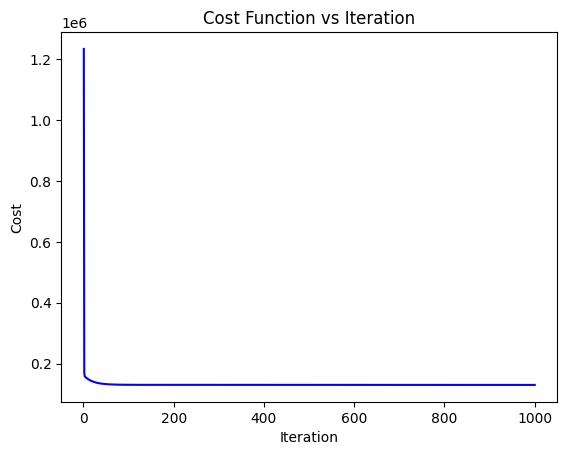

In [ ]:
# plot cost vs iteration
plt.plot(range(1,1001), cost_hist, color='blue')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function vs Iteration')
plt.show()

### Performace evaluation

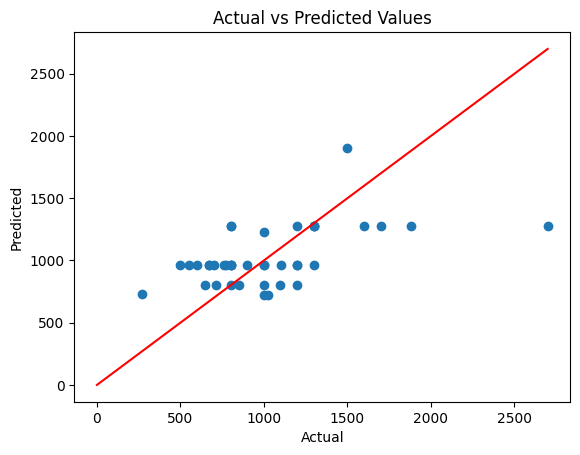

In [ ]:
#plot Actual vs Predict
plt.scatter(y_vector, Y_hat)
plt.plot(range(2700), color='red')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values') 
plt.show()

## Testing Model

In [ ]:
def convert01(CPU, Year):
    CPU = CPU.lower()
    
     # --- APPLE SILICON (M-Series) ---
    if 'm1' in CPU: return 8, 8
    if 'm2' in CPU: return 8, 8
    if 'm3' in CPU: return 8, 8
    if 'm4' in CPU: return 10, 10 # Released 2024+
    if 'm5' in CPU: return 12, 12 # Future/2026 Prediction

    # --- INTEL CORE i3 (Entry Level) ---
    if 'i3' in CPU:
        if Year >= 2024: return 8, 12  # 14th Gen (e.g., 14100 has 4P+0E = 4 cores, 8 threads, but newer i3 may get E-cores)
        if Year >= 2022: return 4, 8   # 12th/13th Gen (4 cores, 8 threads)
        return 2, 4                     # Older Dual-core i3

    # --- INTEL CORE i5 (Mid Range) ---
    if 'i5' in CPU:
        if Year >= 2024: return 14, 20  # 14th Gen (e.g., 14600K: 6P+8E = 14 cores, 20 threads)
        if Year >= 2022: return 12, 16  # 12th/13th Gen Hybrid (e.g., 12600K: 6P+4E = 10 cores, 16 threads)
        if Year >= 2018: return 6, 12   # 8th-11th Gen (6 cores, 12 threads)
        return 4, 4                      # Very old i5 (4 cores, 4 threads)

    # --- INTEL CORE i7 (High End) ---
    if 'i7' in CPU:
        if Year >= 2024: return 16, 24  # 14th Gen (e.g., 14700K: 8P+12E = 20 cores, 28 threads, but laptop versions differ)
        if Year >= 2022: return 14, 20  # 12th/13th Gen Hybrid (8P+8E = 16 cores, 24 threads for desktop, laptop lower)
        if Year >= 2018: return 8, 16   # 8th-11th Gen (8 cores, 16 threads)
        return 4, 8                       # Older Quad-core i7

    # --- INTEL CORE i9 (Enthusiast) ---
    if 'i9' in CPU:
        if Year >= 2024: return 24, 32  # 14th Gen (e.g., 14900K: 8P+16E = 24 cores, 32 threads)
        if Year >= 2022: return 24, 32  # 12th/13th Gen (8P+16E for desktop)
        if Year >= 2018: return 10, 20  # 9th-11th Gen (10 cores, 20 threads)
        return 8, 16                      # Very old i9 (8 cores, 16 threads)

    # --- AMD RYZEN 3 (Entry Level) ---
    if 'ryzen 3' in CPU or 'r3' in CPU:
        if Year >= 2024: return 4, 8    # Zen 4 (4 cores, 8 threads)
        if Year >= 2020: return 4, 8    # Zen 2/3 (4 cores, 8 threads)
        return 4, 4                        # Zen/Zen+ (4 cores, 4 threads)

    # --- AMD RYZEN 5 (Mid Range) ---
    if 'ryzen 5' in CPU or 'r5' in CPU:
        if Year >= 2024: return 6, 12   # Zen 4 (6 cores, 12 threads)
        if Year >= 2020: return 6, 12   # Zen 2/3 (6 cores, 12 threads)
        if Year >= 2018: return 6, 12   # Zen+ (6 cores, 12 threads)
        return 4, 8                        # Zen (4 cores, 8 threads)

    # --- AMD RYZEN 7 (High End) ---
    if 'ryzen 7' in CPU or 'r7' in CPU:
        if Year >= 2024: return 8, 16   # Zen 4/5 (8 cores, 16 threads)
        if Year >= 2020: return 8, 16   # Zen 2/3 (8 cores, 16 threads)
        if Year >= 2018: return 8, 16   # Zen+ (8 cores, 16 threads)
        return 8, 8                        # Zen (8 cores, 8 threads)

    # --- AMD RYZEN 9 (Enthusiast) ---
    if 'ryzen 9' in CPU or 'r9' in CPU:
        if Year >= 2024: return 16, 32  # Zen 4/5 (e.g., 7950X: 16 cores, 32 threads)
        if Year >= 2020: return 16, 32  # Zen 2/3 (e.g., 5950X: 16 cores, 32 threads)
        return 12, 24                       # Zen+ (12 cores, 24 threads)

    # --- AMD THREADRIPPER (Workstation) ---
    if 'threadripper' in CPU or 'tr' in CPU:
        if Year >= 2022: return 64, 128 # Zen 3/4 Threadripper
        return 32, 64                       # Older Threadripper
        
    return np.nan, np.nan

## Input Variable

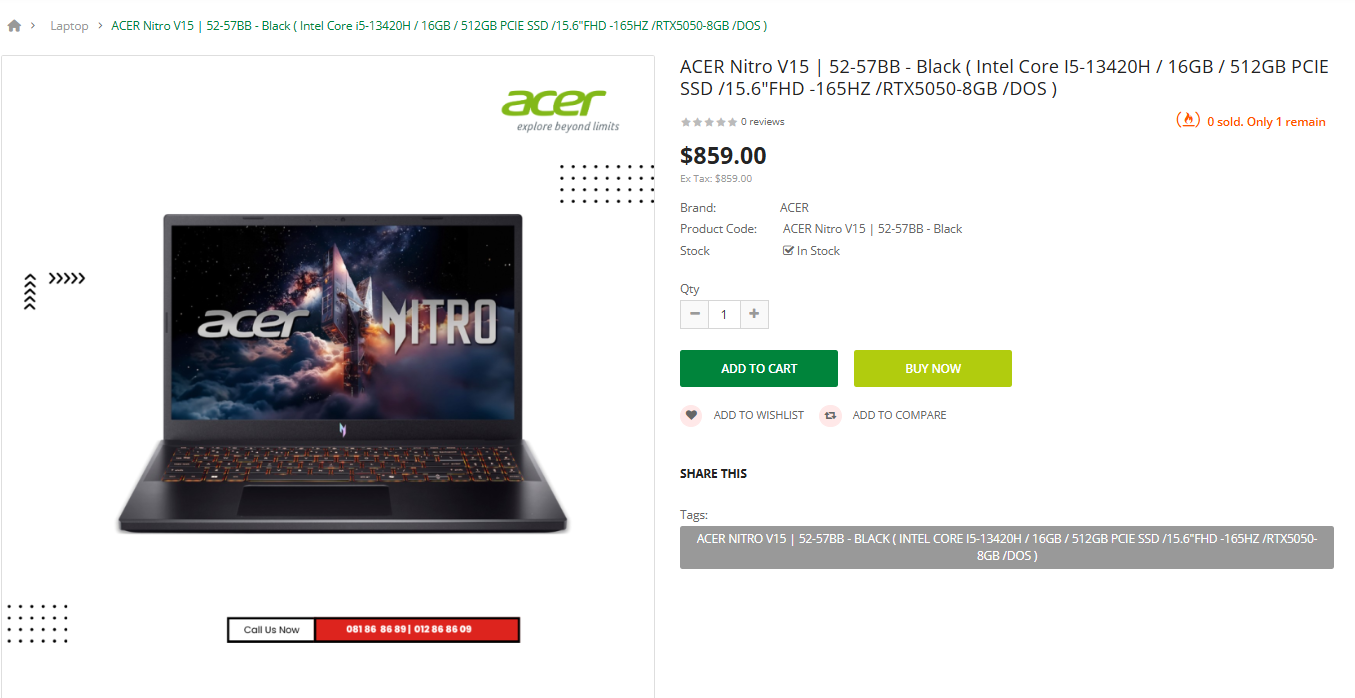

In [ ]:
# Input : Brand, CPU, RAM, Storage, Screen, year_Buy

Input_01 = ['Acer', "Intel core i5", 16, 512, 15.6,  2026]
Input_02 = Input_01[2:6]

In [ ]:
Core_Thread = list(convert01(Input_01[1], Input_01[5]))


B_Rating = Brand_ratings[Input_01[0]]
Input_02.append(B_Rating)
Input_02.append(Core_Thread[0])
Input_02.append(Core_Thread[1])

Input_02 = np.array(Input_02)
Input_02

array([  16. ,  512. ,   15.6, 2026. ,    7. ,   14. ,   20. ])

In [ ]:
# concatenate x_scaled with a column of 1s
Input_03 = np.insert(Input_02, 0, 1)

In [ ]:
Input_03

array([1.000e+00, 1.600e+01, 5.120e+02, 1.560e+01, 2.026e+03, 7.000e+00,
       1.400e+01, 2.000e+01])

## Predicted Price

In [ ]:
Predicted_Price_of_laptop = np.matmul(Input_03, theta)
print(f"The prediction price of a latop with specs {Input_01} is {Predicted_Price_of_laptop[0]:.4f} USD.")

The prediction price of a latop with specs ['Acer', 'Intel core i5', 16, 512, 15.6, 2026] is 961.6353 USD.
